# Assignment 1
Medical Insurance Cost Prediction

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
Numerical: ['age', 'bmi', 'children', 'charges']
Categorical: ['sex', 'smoker', 'region']
T

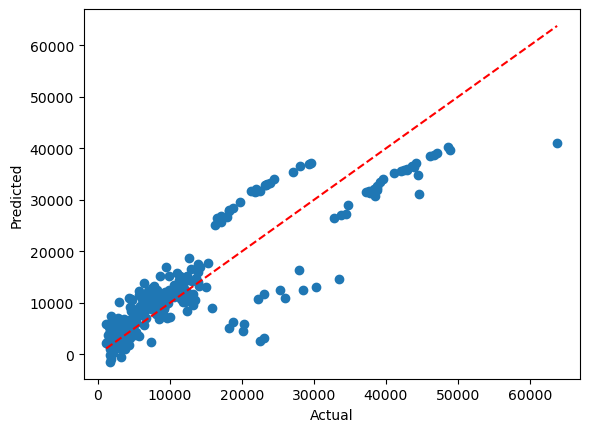

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df=pd.read_csv('insurance.csv')
print(df.head())
print(df.info())
print('Numerical:',df.select_dtypes(include=np.number).columns.tolist())
print('Categorical:',df.select_dtypes(exclude=np.number).columns.tolist())
print('Target: charges')
print(df.isnull().sum())
le=LabelEncoder()
for c in ['sex','smoker','region']:
    df[c]=le.fit_transform(df[c])
X=df.drop('charges',axis=1)
y=df['charges']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
r2=r2_score(y_test,pred)
print(mae,mse,r2)
plt.scatter(y_test,pred)
plt.xlabel('Actual');plt.ylabel('Predicted')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()


## Observations
1. The model predicts insurance charges reasonably well.
2. Smoking status and BMI strongly influence charges.
3. Some prediction errors remain for extreme values.

## Conclusion
Multiple Linear Regression was used to predict medical insurance charges using age, sex, BMI, children, smoker status, and region. After preprocessing and encoding categorical variables, the model was trained and evaluated using MAE, MSE, and R² score. Smoking status, BMI, and age were major factors affecting insurance costs. The model provides a good baseline for prediction, but linear regression assumes a linear relationship between features and target, which may not capture complex real-world patterns. More advanced models such as Random Forest or XGBoost may improve prediction accuracy.